# E-Commerce Customer Analytics
## RFM Segmentation, Cohort Retention & Market Basket Insights

This notebook is a 3-day sprint style advanced EDA project focused on:
-Customer Behaviour

- Revenue trends

- RFM segmentation

- Cohort Retention

- Market Basket Insights


**Portfolio goal:** create a clean GitHub/LinkedIn ready analytics story where every major chart leads to a buisness insights abd action.



## 1. Problem Statement 

E_commerce businesses need to understand which customers are valuable, which customers are likely to churn, which products drive sales, and which product combinations  can improve cross-selling.

This analysis answers:

- What are the main revenue and order trends.

- Which products, categories, and countries contribute more to sale?

- Which customers are loyal, new, at risk , lost or champions? 

- How well does the business retain customers after first purchase?

- Which products are commonly purchased together?


## 2. Setup

In [28]:
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option('display.max_columns',100)
pd.set_option('display.float_format',lambda x: f'{x:,.2f}')

sns.set_theme(style = 'whitegrid' , context= 'notebook')
plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['axes.titleweight'] = 'bold'


DATA_PATH = Path('data/raw/online_retail_II.xlsx')
RANDOM_STATE = 42



## 3. Dataset Overview

Place your dataset in `data/raw` and update `DATA_PATH`. The helper below supports CSV and Excel files.

In [29]:
def load_data(path:Path) -> pd.DataFrame:
    if path.suffix.lower() in ['.xls','.xlsx']:
        return pd.read_excel(path)
    return pd.read_csv(path, encoding='unicode_escape')

df_raw = load_data(DATA_PATH)
df = df_raw.copy()

display(df.head())
display(df.info())
display(df.describe(include='all').T.head(20))
print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]:,} ')

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom


<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 32.1+ MB


None

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Invoice,"525,461.00","28,816.00","537,434.00",675.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,525461,4632,85123A,3516,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,522533,4681,WHITE HANGING HEART T-LIGHT HOLDER,3549,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,"525,461.00",NaN,NaN,NaN,10.34,"-9,600.00",1.00,3.00,10.00,"19,152.00",107.42
InvoiceDate,525461,NaN,NaN,NaN,2010-06-28 11:37:36.845018,2009-12-01 07:45:00,2010-03-21 12:20:00,2010-07-06 09:51:00,2010-10-15 12:45:00,2010-12-09 20:01:00,NaN
Price,"525,461.00",NaN,NaN,NaN,4.69,"-53,594.36",1.25,2.10,4.21,"25,111.09",146.13
Customer ID,"417,534.00",NaN,NaN,NaN,"15,360.65","12,346.00","13,983.00","15,311.00","16,799.00","18,287.00","1,680.81"
Country,525461,40,United Kingdom,485852,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Rows: 525,461 | Columns: 8 


### Column Mapping

Update this mapping if your dataset uses different column names.
Common example: `Invoice` , `StockCode` , `Description` , `Quantity` , `InvoiceDate` , `UnitPrice` , `CustomerID` and `Country`.

In [30]:
column_map = {
    'order_id' : 'Invoice',
    'customer_id' : 'Customer ID',
    'order_date' : 'InvoiceDate',
    'product' : 'Description',
    'quantity' : 'Quantity',
    'unit_price' : 'Price',
    'country' : 'Country',
   'category' : None,
   'city' : None    
}

available_map = {new: old for new, old in column_map.items() if old in df.columns}
df = df.rename(columns={old:new for new, old in available_map.items()})

required_cols = ['order_id','customer_id','order_date','product','quantity','unit_price']
missing_required = [col for col in required_cols if col not in df.columns]
missing_required


[]

## 4. Data cleaning

Cleaning check includes missing values, duplicates, data types, data conversion and invalid quantity/price values.

In [31]:
missing_summary = (
    df.isna().sum()
    .to_frame('missing_count')
    .assign(missing_pct = lambda x: x['missing_count']/ len(df) * 100)
    .sort_values('missing_count',ascending= False)
)

duplicate_count = df.duplicated().sum()

display(missing_summary.head(15))
print(f'duplicate rows: {duplicate_count:,}')

,missing_count,missing_pct
customer_id,107927,20.54
product,2928,0.56
StockCode,0,0.00
order_id,0,0.00
quantity,0,0.00
order_date,0,0.00
unit_price,0,0.00
country,0,0.00


duplicate rows: 6,865


In [32]:
df['order_date'] = pd.to_datetime(df['order_date'], errors= 'coerce') 
df['customer_id'] = df['customer_id'].astype('string') 
df['order_id'] = df['order_id'].astype('string')
df['product'] = df['product'].astype('string').str.strip()

df_clean = (
    df
    .drop_duplicates()
    .dropna(subset=['order_id','customer_id','order_date','product','quantity','unit_price'])
    .query('quantity > 0 and unit_price > 0')
    .copy()
)

print(f'Raw rows: {len(df):,}')
print(f'Clean rows: {len(df_clean):,}')
print(f'Removed rows: {len(df) - len(df_clean):,}')


Raw rows: 525,461
Clean rows: 400,916
Removed rows: 124,545


**Cleaning insight:**

- Invalid returns/Cancelled transactions were removed because this project focuses on positive purchase behavior.
- Missing customer IDs were removed because RFM, cohort and basket analysis require reliable customer IDs.
- Action: Analyze  returns separately in a future project.


## 5. Feature Engineering

In [33]:
df_clean = df_clean.assign(
    revenue = lambda x: x['quantity'] * x['unit_price'],
    order_month = lambda x: x['order_date'].dt.to_period('M').dt.to_timestamp(),
    year = lambda x: x['order_date'].dt.year,
    month_name = lambda x: x['order_date'].dt.month_name(),
    month = lambda x: x['order_date'].dt.month
)

customer_matrix = (
    df_clean.groupby('customer_id')
    .agg(
        first_purchase = ('order_date', 'min'),
        last_purchase = ('order_date', 'max'),
        total_orders= ('order_id', 'nunique'),
        total_quantity = ('quantity', 'sum'),
        total_revenue = ('revenue', 'sum'),
        avg_order_value = ('revenue', lambda s: s.sum() / df_clean.loc[s.index, 'order_id'].nunique())     
    )
    .reset_index()
)

display(df_clean.head())
display(customer_matrix.head())

,order_id,StockCode,product,quantity,order_date,unit_price,customer_id,country,revenue,order_month,year,month_name,month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40,2009-12-01,2009,December,12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00,2009-12-01,2009,December,12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00,2009-12-01,2009,December,12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80,2009-12-01,2009,December,12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00,2009-12-01,2009,December,12


,customer_id,first_purchase,last_purchase,total_orders,total_quantity,total_revenue,avg_order_value
0,12346.0,2009-12-14 08:34:00,2010-06-28 13:53:00,11,70,372.86,33.90
1,12347.0,2010-10-31 14:20:00,2010-12-07 14:57:00,2,828,"1,323.32",661.66
2,12348.0,2010-09-27 14:59:00,2010-09-27 14:59:00,1,373,222.16,222.16
3,12349.0,2010-04-29 13:20:00,2010-10-28 08:23:00,3,993,"2,671.14",890.38
4,12351.0,2010-11-29 15:23:00,2010-11-29 15:23:00,1,261,300.93,300.93


## 6. Core EDA

In [34]:
summary_kpis = pd.Series({
    'Total Revenue' : df_clean['revenue'].sum(),
    'Total Order' : df_clean['order_id'].nunique(),
    'Total Customer' : df_clean['customer_id'].nunique(),
    'Average Order Value' : df_clean.groupby('order_id')['revenue'].sum().mean(),
    'Average Revenue pr Customer' : df_clean.groupby('customer_id')['revenue'].sum().mean()
})

summary_kpis.to_frame('value')

,value
Total Revenue,"8,798,233.74"
Total Order,"19,213.00"
Total Customer,"4,312.00"
Average Order Value,457.93
Average Revenue pr Customer,"2,040.41"


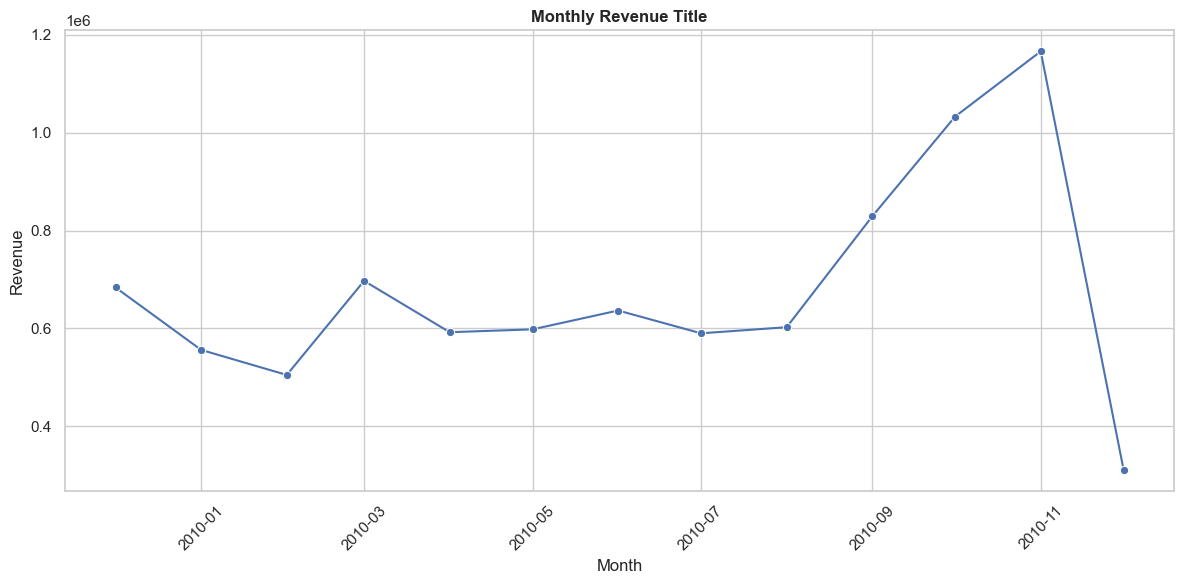

In [48]:
monthly_sales = (
    df_clean.groupby('order_month', as_index= False)
    .agg(revenue = ('revenue','sum'), orders = ('order_id','nunique'), customers = ('customer_id','nunique'))
    .sort_values('order_month')
)

ax = sns.lineplot(data= monthly_sale, x= 'order_month', y = 'revenue', marker = 'o')
ax.set_title('Monthly Revenue Title')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

**Business Insights:**

- Identify strongest growth and sharpest decline months from the line chart, then compare campaigns and inventory.
- If revenue grows while customer count stays flat, business is increasing basket size.
- Create monthly campaign review for months with unusual spikes or declines.

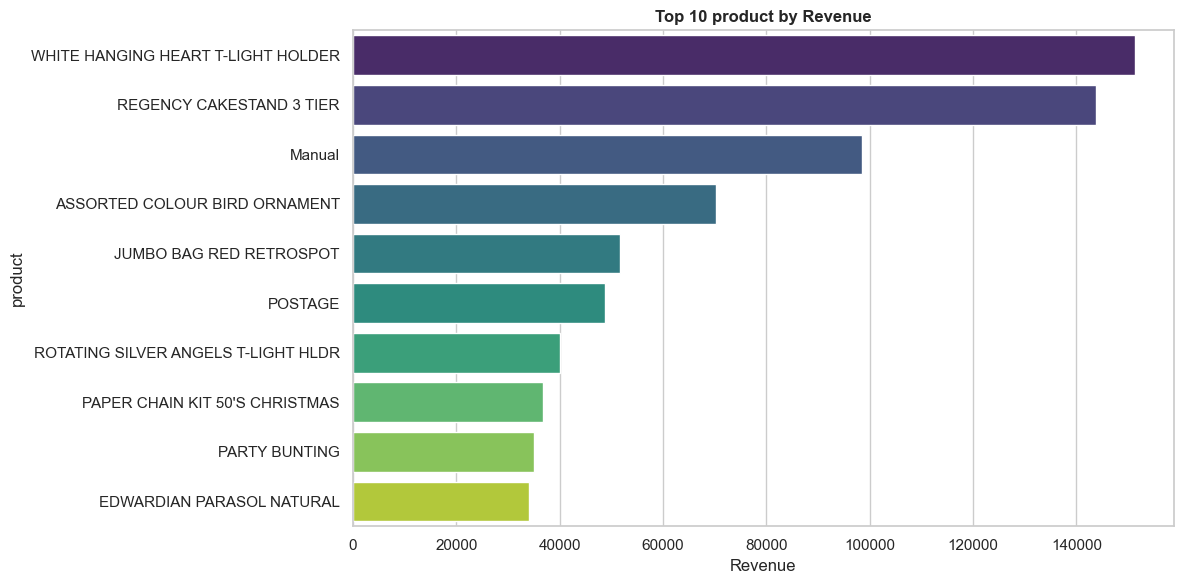

In [36]:
top_products = (
    df_clean.groupby('product', as_index= False)
    .agg(revenue = ('revenue', 'sum'), quantity = ('quantity','sum'), orders = ('order_id', 'nunique'))
    .sort_values('revenue', ascending=False)
    .head(10)
)

ax = sns.barplot(data=top_products, x='revenue', y= 'product',palette= 'viridis', hue= 'product', legend=False)
ax.set_title('Top 10 product by Revenue')
ax.set_xlabel('Revenue')
ax.set_ylabel('product')
plt.tight_layout()
plt.show()

**Business Insights:**

- High-revenue products should receive priority in inventory planning, homepage placement, and paid campaigns.
- Compare revenue with quantity sold: high revenue but lower quantity indicates premium products.
- Action: protect stock levels for top products and test bundles around products with strong order penetration.

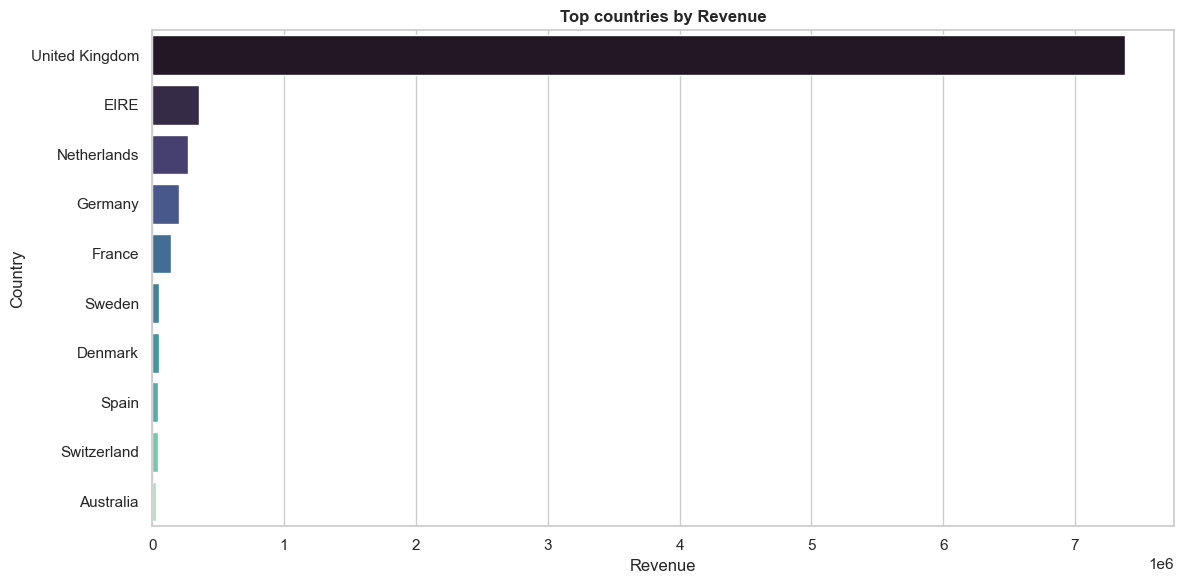

In [37]:
if 'country' in df_clean.columns:
    top_location = (
        df_clean.groupby('country', as_index= False)
        .agg(revenue= ('revenue','sum'), customer= ('customer_id','nunique'))
        .sort_values('revenue',ascending=False)
        .head(10)
    )

    ax= sns.barplot(data= top_location, x= 'revenue', y= 'country',palette='mako', hue='country', legend=False)
    ax.set_title('Top countries by Revenue')
    ax.set_xlabel('Revenue')
    ax.set_ylabel('Country')
    plt.tight_layout()
    plt.show()

else:
    print("NO Country column available.")

**Business Insights:**

- Top countries show where demand is already proven and where localized marketing can scale faster.
- Revenue is concentrated in a small number of countries, creating potential concentration risk. Secondary markets should be investigated for future growth.
- Action: create location-specific campaigns and evaluate shipping and delivery times by region.

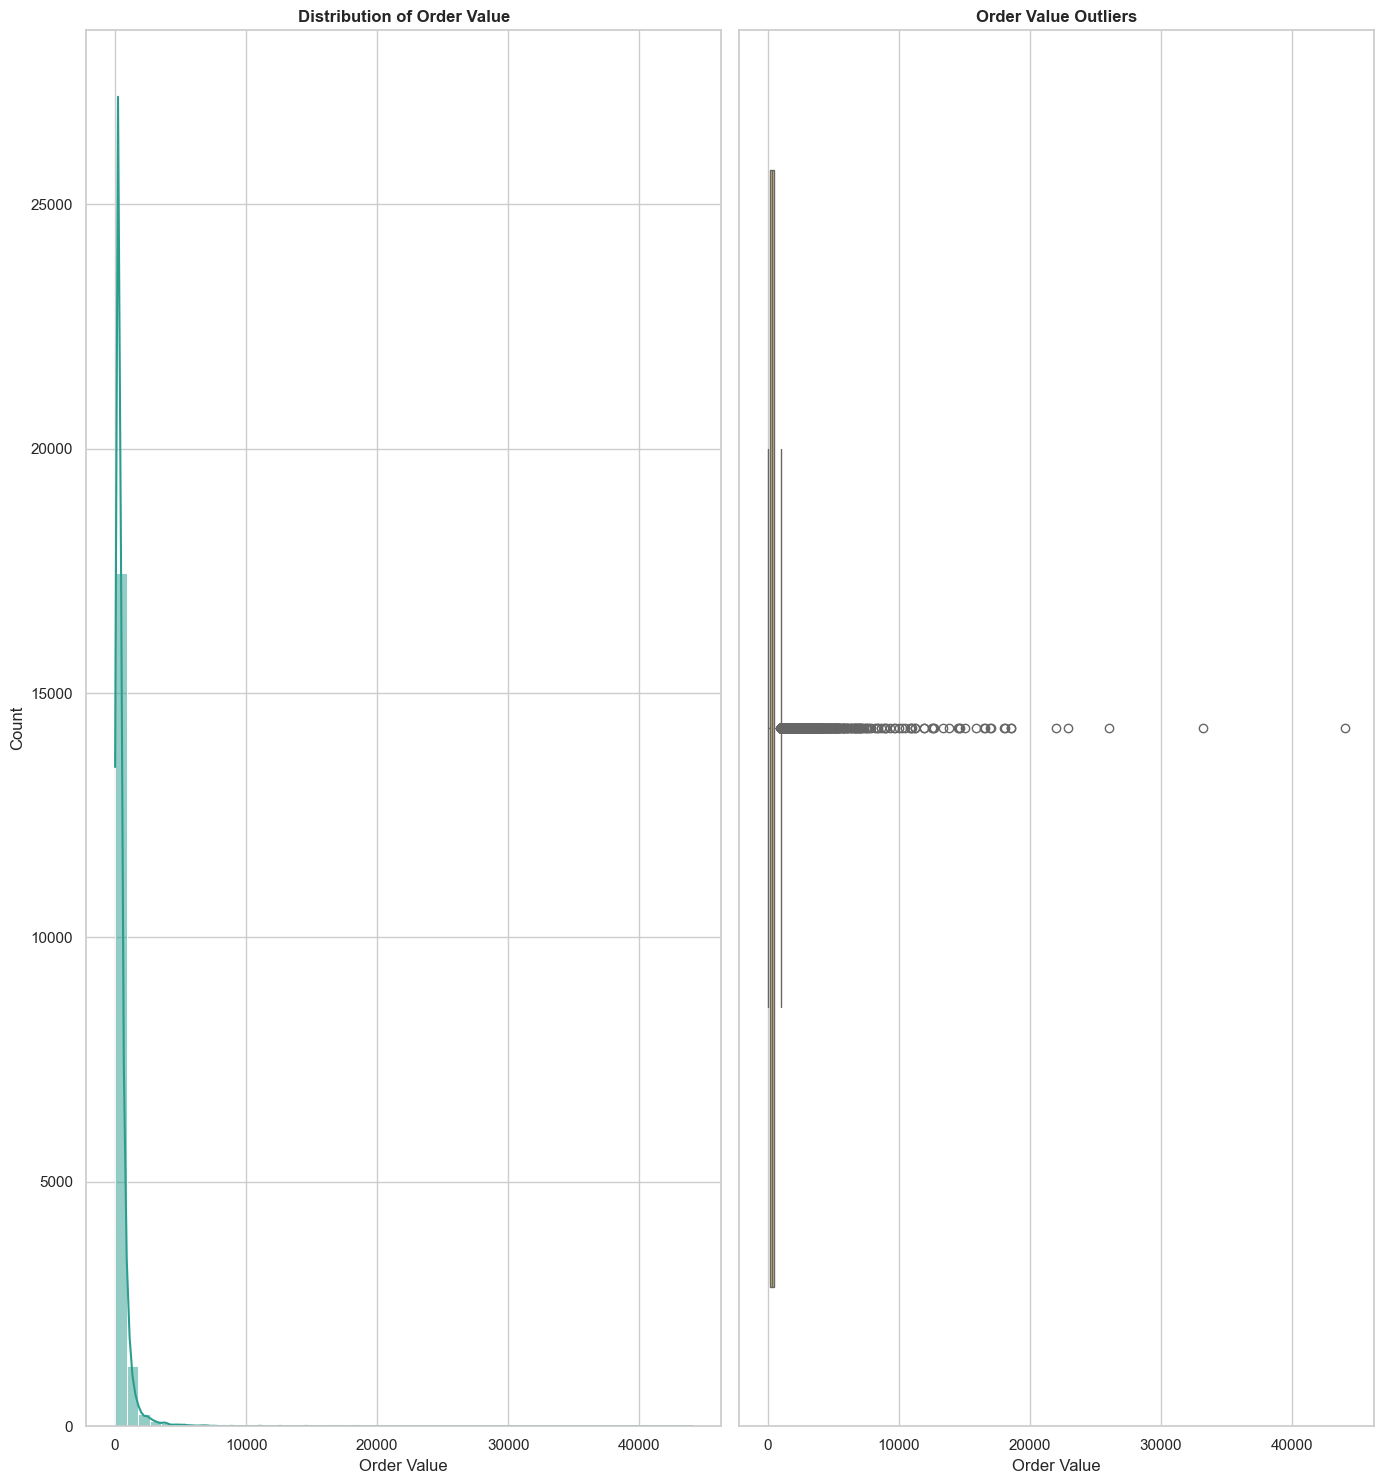

In [38]:
order_values = df_clean.groupby('order_id', as_index= False).agg (order_value=('revenue','sum'))

fig, axes = plt.subplots(1, 2, figsize =(14,15))
sns.histplot(order_values['order_value'], bins= 50, kde = True,ax=axes[0],color='#2a9d8f')
axes[0].set_title('Distribution of Order Value')
axes[0].set_xlabel('Order Value')

sns.boxplot(data = order_values , x='order_value',ax=axes[1], color='#e9c46a')
axes[1].set_title('Order Value Outliers')
axes[1].set_xlabel('Order Value')
plt.tight_layout()
plt.show()

**Business Insights:**

- Right skewed order value distribution mean small share of high value basket contributes most to revenue.
- Outliers may represent whole sale or bulk customers who should not be treated same as one time small buyers.
- Action: use free shipping thresholds and bundle to increase average order value.

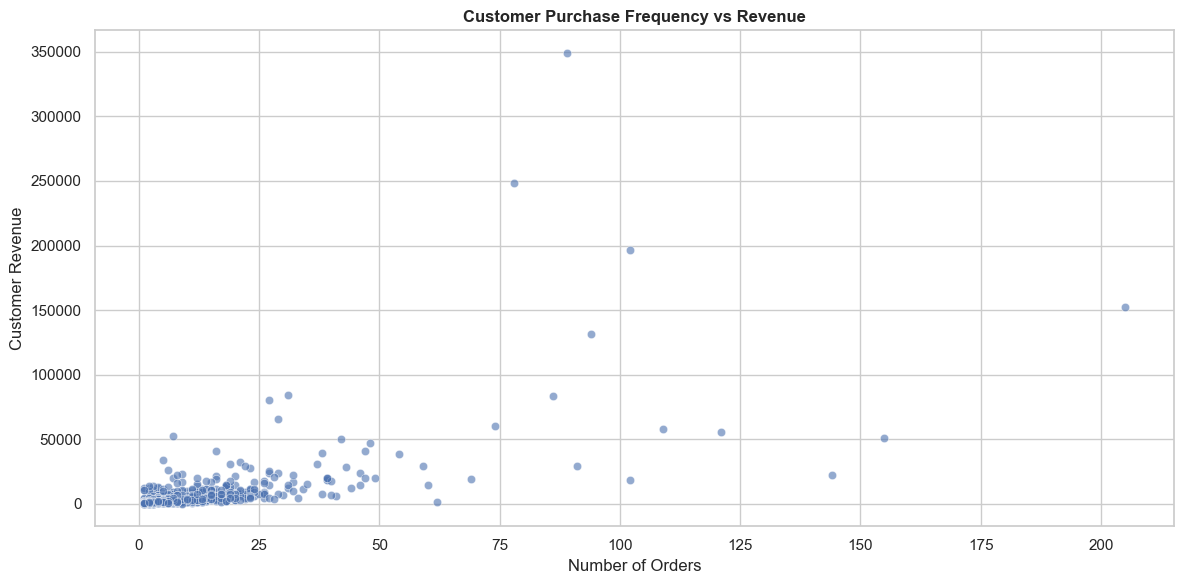

In [39]:
purchase_behavior = (
    df_clean.groupby('customer_id', as_index=False)
    .agg(orders= ('order_id','nunique'), revenue = ('revenue', 'sum'))
) 

ax= sns.scatterplot(data= purchase_behavior, x= 'orders' , y='revenue', alpha = 0.6)
ax.set_title('Customer Purchase Frequency vs Revenue')
ax.set_xlabel('Number of Orders')
ax.set_ylabel('Customer Revenue')
plt.tight_layout()
plt.show()

**Business insight:**

- Customers with high frequency and high revenue are strongest 
candidates for loyalty rewards and VIP treatment.
- Low frequency but high revenue customers may be seasonal 
or bulk buyers needing timely reactivation.
- Action: separate lifecycle campaigns for frequent buyers, 
high value occasional buyers, and low value one time buyers.

## 7. RFM Analysis

In [40]:
analysis_data= df_clean['order_date'].max() + pd.Timedelta(days=1)

rfm= (
    df_clean.groupby('customer_id')
    .agg(
        recency = ('order_date' , lambda  x: (analysis_data - x.max()).days),
        frequency = ('order_id','nunique'),
        monetary=('revenue','sum')
    )
    .reset_index()
)

rfm['r_score'] = pd.qcut(rfm['recency'].rank(method= 'first'),5, labels= [5,4,3,2,1]).astype(int)
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method= 'first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['m_score'] = pd.qcut(rfm['monetary'].rank(method = 'first'),5, labels = [1,2,3,4,5]).astype(int)
rfm['rfm_score'] = rfm[['r_score', 'f_score','m_score']].sum(axis=1)



In [41]:
conditions = [
    (rfm['r_score'] >= 4) & (rfm['f_score'] >= 4) & (rfm['m_score'] >= 4),
    (rfm['r_score'] >= 3) & (rfm['f_score'] >= 4),
    (rfm['r_score'] >= 4) & (rfm['f_score'] <= 2),
    (rfm['r_score'] == 3) & (rfm['f_score'] <= 3),
    (rfm['r_score'] <= 2) & (rfm['f_score'] >= 3),
    (rfm['r_score'] <= 2) & (rfm['f_score'] <= 2)
]
segments = ['Champions', 'Loyal Customers', 'New Customers', 
            'About to Sleep', 'At Risk', 'Lost Customers']

rfm['segment'] = np.select(conditions, segments, default='Potential Loyalists')

display(rfm.head())
display(rfm['segment'].value_counts())

,customer_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,segment
0,12346.0,165,11,372.86,2,5,2,9,At Risk
1,12347.0,3,2,"1,323.32",5,2,4,11,New Customers
2,12348.0,74,1,222.16,2,1,1,4,Lost Customers
3,12349.0,43,3,"2,671.14",3,3,5,11,About to Sleep
4,12351.0,11,1,300.93,5,1,2,8,New Customers


segment
Lost Customers         1025
Champions               911
At Risk                 700
About to Sleep          547
Loyal Customers         488
New Customers           360
Potential Loyalists     281
Name: count, dtype: int64

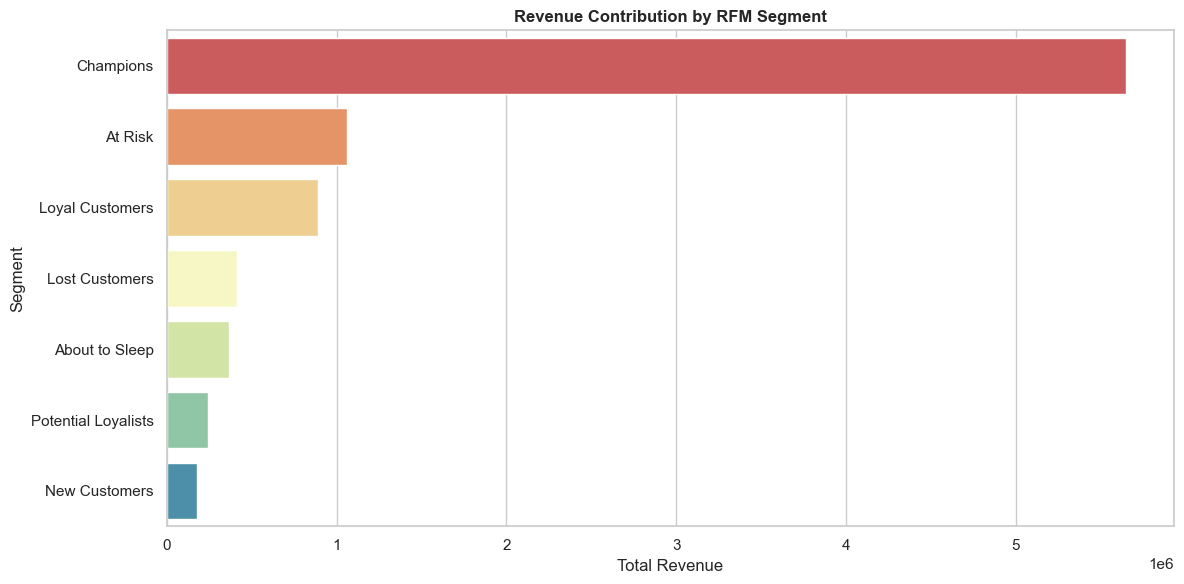

,segment,customers,avg_recency,avg_frequency,total_monetary,avg_monetary,customer_share
2,Champions,911,13.31,11.74,"5,647,909.97","6,199.68",21.13
1,At Risk,700,147.68,3.78,"1,060,864.34","1,515.52",16.23
4,Loyal Customers,488,39.14,5.41,"890,937.56","1,825.69",11.32
3,Lost Customers,1025,212.49,1.13,"414,000.12",403.90,23.77
0,About to Sleep,547,52.68,1.67,"367,642.04",672.11,12.69
6,Potential Loyalists,281,17.42,2.46,"239,892.93",853.71,6.52
5,New Customers,360,19.51,1.30,"176,986.78",491.63,8.35


In [42]:
segment_summary = (
    rfm.groupby('segment', as_index=False)
    .agg(
        customers=('customer_id', 'nunique'),
        avg_recency=('recency', 'mean'),
        avg_frequency=('frequency', 'mean'),
        total_monetary=('monetary', 'sum'),
        avg_monetary=('monetary', 'mean')
    )
    .assign(customer_share=lambda x: x['customers'] / x['customers'].sum() * 100)
    .sort_values('total_monetary', ascending=False)
)

ax = sns.barplot(data=segment_summary, y='segment', x='total_monetary', 
                 palette='Spectral', hue='segment', legend=False)
ax.set_title('Revenue Contribution by RFM Segment')
ax.set_xlabel('Total Revenue')
ax.set_ylabel('Segment')
plt.tight_layout()
plt.show()

display(segment_summary)

**Business insight:**

- Champions generate highest revenue and purchased recently — 
protect them with VIP perks and early access.
- At Risk customers have meaningful past spend but are becoming 
inactive — urgent reactivation needed.
- Action: prioritize Champions for VIP perks, At Risk customers 
for win-back campaigns, and New Customers for second purchase.

In [43]:
fig = px.scatter(
    rfm,
    x='recency',
    y='monetary',
    size='frequency',
    color='segment',
    hover_data=['customer_id', 'frequency'],
    title='Interactive RFM Customer Map'
)
fig.update_layout(template='plotly_white')
fig.show()

## 8. Cohort Retention Analysis

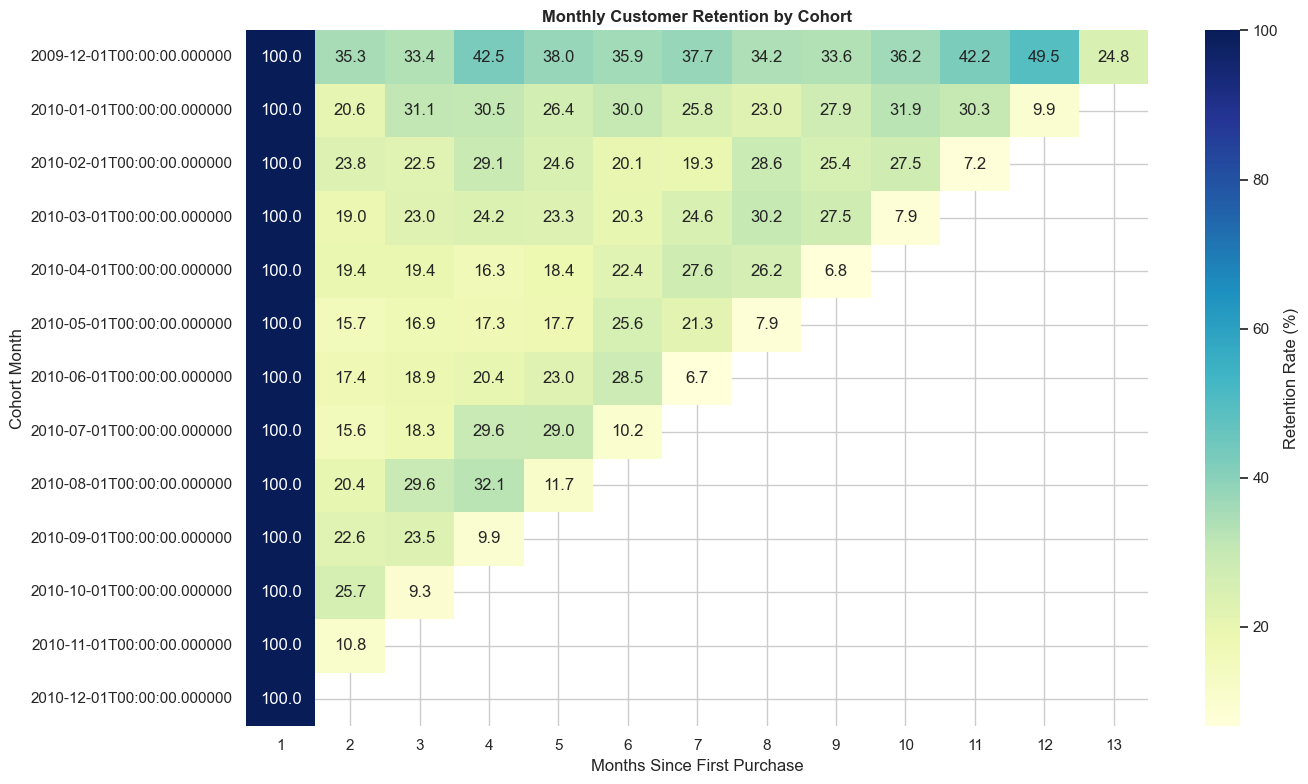

In [44]:
cohort_data = df_clean[['customer_id', 'order_id', 'order_date', 'order_month']].drop_duplicates().copy()
cohort_data['cohort_month'] = cohort_data.groupby('customer_id')['order_month'].transform('min')

cohort_counts = (
    cohort_data.groupby(['cohort_month', 'order_month'])['customer_id']
    .nunique()
    .reset_index(name='customers')
)

cohort_counts['cohort_index'] = (
    (cohort_counts['order_month'].dt.year - cohort_counts['cohort_month'].dt.year) * 12
    + (cohort_counts['order_month'].dt.month - cohort_counts['cohort_month'].dt.month)
    + 1
)

cohort_pivot = cohort_counts.pivot_table(index='cohort_month', columns='cohort_index', values='customers')
cohort_sizes = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_sizes, axis=0) * 100

plt.figure(figsize=(14, 8))
ax = sns.heatmap(retention, annot=True, fmt='.1f', cmap='YlGnBu', 
                 cbar_kws={'label': 'Retention Rate (%)'})
ax.set_title('Monthly Customer Retention by Cohort')
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Cohort Month')
plt.tight_layout()
plt.show()

**Business insight:**

- First to second month retention is low — onboarding 
and early purchase experience needs improvement.
- Cohorts with better retention should be investigated 
for campaigns that can be repeated.
- Action: build second purchase journey within 30 days 
using personalized recommendations and incentives.

## 9. Basic Market Basket Analysis

In [45]:
basket_products = (
    df_clean.groupby('order_id')['product']
    .apply(lambda x: sorted(set(x.dropna())))
    .reset_index(name='products')
)

product_pairs = (
    basket_products.assign(pair=basket_products['products'].apply(lambda products: list(combinations(products, 2))))
    .explode('pair')
    .dropna(subset=['pair'])
)

top_pairs = (
    product_pairs['pair']
    .value_counts()
    .head(15)
    .rename_axis('pair')
    .reset_index(name='orders_together')
)
top_pairs[['product_1', 'product_2']] = pd.DataFrame(top_pairs['pair'].tolist(), index=top_pairs.index)
top_pairs = top_pairs[['product_1', 'product_2', 'orders_together']]

display(top_pairs)

,product_1,product_2,orders_together
0,RED HANGING HEART T-LIGHT HOLDER,WHITE HANGING HEART T-LIGHT HOLDER,722
1,STRAWBERRY CERAMIC TRINKET BOX,SWEETHEART CERAMIC TRINKET BOX,622
2,WOODEN FRAME ANTIQUE WHITE,WOODEN PICTURE FRAME WHITE FINISH,554
3,HOME BUILDING BLOCK WORD,LOVE BUILDING BLOCK WORD,522
4,HEART OF WICKER LARGE,HEART OF WICKER SMALL,491
5,60 TEATIME FAIRY CAKE CASES,PACK OF 72 RETRO SPOT CAKE CASES,478
6,60 TEATIME FAIRY CAKE CASES,PACK OF 60 PINK PAISLEY CAKE CASES,468
7,LUNCH BAG SPACEBOY DESIGN,LUNCH BAG SUKI DESIGN,454
8,WHITE HANGING HEART T-LIGHT HOLDER,WOODEN FRAME ANTIQUE WHITE,442
9,PACK OF 60 PINK PAISLEY CAKE CASES,PACK OF 72 RETRO SPOT CAKE CASES,409


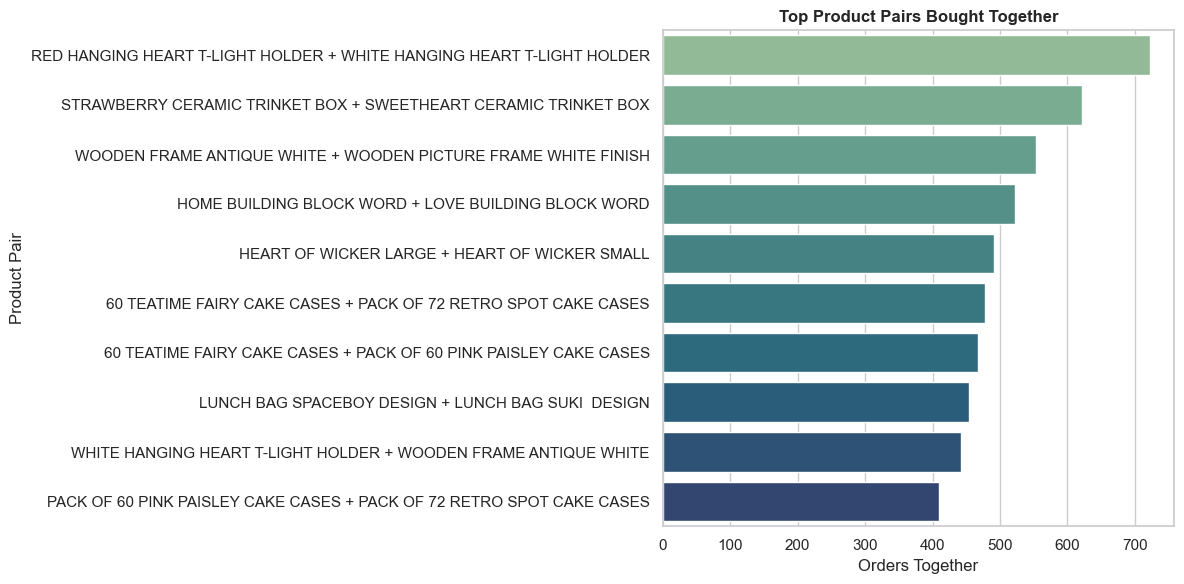

In [46]:
top_pairs_plot = top_pairs.assign(
    pair_label=lambda x: x['product_1'] + ' + ' + x['product_2']
).head(10)

ax = sns.barplot(data=top_pairs_plot, x='orders_together', y='pair_label', 
                 palette='crest', hue='pair_label', legend=False)
ax.set_title('Top Product Pairs Bought Together')
ax.set_xlabel('Orders Together')
ax.set_ylabel('Product Pair')
plt.tight_layout()
plt.show()

**Business insight:**

- Frequently bought together pairs are strong candidates 
for bundle offers and checkout recommendations.
- If pairs include high margin and popular products, 
bundles can lift profit as well as order value.
- Action: test bundle discounts and "complete the set" 
recommendations for top product pairs.

## 10. Plotly Interactive Visualizations

In [50]:
fig = px.line(
    monthly_sales,
    x='order_month',
    y='revenue',
    markers=True,
    title='Interactive Monthly Revenue Trend'
)
fig.update_layout(template='plotly_white', xaxis_title='Month', yaxis_title='Revenue')
fig.show()

fig = px.bar(
    top_products.sort_values('revenue'),
    x='revenue',
    y='product',
    orientation='h',
    title='Interactive Top Products by Revenue'
)
fig.update_layout(template='plotly_white', xaxis_title='Revenue', yaxis_title='Product')
fig.show()

fig = px.pie(
    segment_summary,
    names='segment',
    values='customers',
    hole=0.45,
    title='Customer Mix by RFM Segment',
    color_discrete_sequence=px.colors.qualitative.Pastel
)
fig.update_layout(template='plotly_white')
fig.show()

## 11. Final Insights and Actions

1. **Revenue trend:** Revenue peaked in November 2010 and dropped in December 2010.
   **Action:** investigate campaigns, stock availability, and seasonality behind these movements.

2. **Top product concentration:** WHITE HANGING HEART T-LIGHT HOLDER contributed largest share of revenue.
   **Action:** keep high revenue products in stock and use them in homepage placements.

3. **Location opportunity:** United Kingdom dominates revenue, other regions underdeveloped.
   **Action:** create region specific promotions and monitor delivery performance by market.

4. **Order value pattern:** Order values are right skewed with small number of high value baskets.
   **Action:** use free shipping thresholds and bundles to increase average order value.

5. **Champions segment:** Champions generate highest value and purchased recently.
   **Action:** protect them with VIP perks, early access, and loyalty points.

6. **At Risk segment:** 700 valuable customers have not purchased recently.
   **Action:** run win-back campaigns with urgency based incentives.

7. **New customers:** 360 recent low frequency customers need second purchase push.
   **Action:** send onboarding journeys and first to second purchase discounts.

8. **Retention pattern:** Cohort heatmap shows only 20-35% customers return after first purchase.
   **Action:** improve post purchase experience within 30 days.

9. **Bundle opportunity:** RED HANGING HEART + WHITE HANGING HEART bought together 700+ times.
   **Action:** test bundle discounts and checkout cross sells.

10. **Customer strategy:** Different customer groups need different actions.
    **Action:** use RFM segments for targeted CRM planning.

## 12. Business Recommendations

- **Retention:** Focus on second purchase campaigns within 
first 30 days because early repeat behavior is critical 
for long term retention.

- **High value customers:** Build VIP journeys for Champions 
including early access, exclusive discounts, and personalized 
recommendations.

- **Win-back:** Prioritize At Risk customers before they become 
Lost Customers; use previous purchase history to make offers relevant.

- **Bundling:** Use top product pairs to create bundle offers 
and checkout recommendations to increase average order value.

- **Revenue improvement:** Protect inventory for top products, 
review low performing months, and use product level revenue 
insights for campaign planning.

- **CRM strategy:** Use RFM segments for email, SMS, and 
retargeting audiences instead of sending generic promotions 
to all customers.